In [1]:
import numpy as np
import pandas as pd
import torch
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

from domain_shift.core.config import settings
from domain_shift.CycleGAN.data_loader import get_data_loader
from domain_shift.CycleGAN.models import CycleGAN
from domain_shift.data_extraction.process_DRIAMS import DRIAMS_bin_to_df

/home/dive001/Documents/Master/maldi-tof-domain-shift/.venv/lib/python3.11/site-packages/pydantic_settings/main.py:167: UserWarning: A custom validator is returning a value other than `self`.
Returning anything other than `self` from a top level model validator isn't supported when validating via `__init__`.
See the `model_validator` docs (https://docs.pydantic.dev/latest/concepts/validators/#model-validators) for more details.
  super().__init__(


In [2]:
NUMBER_EXECUTIONS = 10

In [3]:
# Load the data
driams_1 = DRIAMS_bin_to_df(settings.DRIAMS_C_PATH)
driams_2 = DRIAMS_bin_to_df(settings.DRIAMS_D_PATH)

In [5]:
# Combine the 'species' columns from both datasets
combined_species = pd.concat([driams_1['species'], driams_2['species']])

# Find the 5 most represented species across both datasets
species_counts = combined_species.value_counts()
top_species = species_counts.index[:5]
top_species = top_species.tolist()
top_species

['Escherichia coli',
 'Staphylococcus aureus',
 'Klebsiella pneumoniae',
 'Proteus mirabilis',
 'Pseudomonas aeruginosa']

In [6]:
# Show the distribution of the most represented species in each dataset
driams_1['species'].value_counts()[top_species], \
driams_2['species'].value_counts()[top_species]

(species
 Escherichia coli          927
 Staphylococcus aureus     738
 Klebsiella pneumoniae     366
 Proteus mirabilis         220
 Pseudomonas aeruginosa    357
 Name: count, dtype: int64,
 species
 Escherichia coli          2013
 Staphylococcus aureus     2174
 Klebsiella pneumoniae     2151
 Proteus mirabilis          623
 Pseudomonas aeruginosa     362
 Name: count, dtype: int64)

In [10]:
# Filter by the 4 species with most representation
filtered_driams_1 = driams_1[driams_1["species"].isin(top_species)]
filtered_driams_2 = driams_2[driams_2["species"].isin(top_species)]

In [11]:
# Show dataset lengths
len(filtered_driams_1), len(filtered_driams_2)

(2608, 7323)

In [46]:
# Train PCA on the first dataset
X = np.vstack(filtered_driams_1["binned_6000"].values)
y = filtered_driams_1["species"].values

pca = PCA(n_components=3)
pca.fit(X)
pca_driams_1 = pca.transform(X)

In [12]:
# Get the data loaders
driams_1_data_loader = get_data_loader(filtered_driams_1)
driams_2_data_loader = get_data_loader(filtered_driams_2)

print("DataLoader 1 length:", len(driams_1_data_loader))
print("DataLoader 2 length:", len(driams_2_data_loader))

DataLoader 1 length: 652
DataLoader 2 length: 1831


In [13]:
# Train the CycleGAN
cycle_gan = CycleGAN()
cycle_gan.train(driams_1_data_loader, driams_2_data_loader)

Epoch 1/5, Loss G: 0.7211158871650696, Loss D 1: 0.24185721576213837, Loss D 2: 0.16010066866874695
Epoch 2/5, Loss G: 0.6929206848144531, Loss D 1: 0.2608579397201538, Loss D 2: 0.20943573117256165
Epoch 3/5, Loss G: 0.7487843632698059, Loss D 1: 0.22574308514595032, Loss D 2: 0.19265404343605042
Epoch 4/5, Loss G: 0.6511873602867126, Loss D 1: 0.23320627212524414, Loss D 2: 0.18690624833106995
Epoch 5/5, Loss G: 0.7036146521568298, Loss D 1: 0.25858086347579956, Loss D 2: 0.176396444439888


In [55]:
# Generate the synthetic data
synthetic_driams_2 = []
for data in driams_2_data_loader:
    output = cycle_gan.generator_2_to_1(data.to("cuda")).cpu().detach()
    synthetic_driams_2.extend(output.cpu().detach().flatten(1))
synthetic_driams_2 = torch.stack(synthetic_driams_2)

In [ ]:
# Test the model on the original driams 2
X = np.vstack(filtered_driams_2["binned_6000"].values)
y = filtered_driams_2["species"].values

# Transform the data using the PCA trained on the first dataset
pca_driams_2 = pca.transform(X)

PCA shape: (7323, 3)


In [59]:
# Test the model on the synthetic driams 2
X = np.vstack(synthetic_driams_2.numpy())
y = filtered_driams_2["species"].values

# Transform the data using the PCA trained on the first dataset
transformed_pca_driams_2 = pca.transform(X)

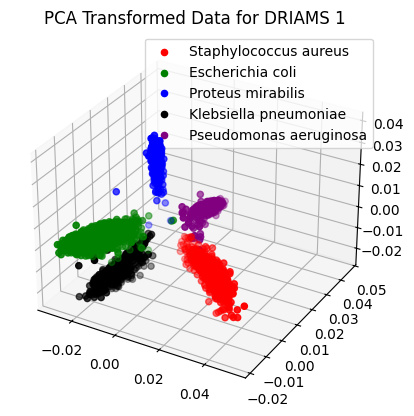

In [88]:
# Ensure you have PCA data and filtered species data
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
colors = ['red', 'green', 'blue', 'black', 'purple']

# Unique species
driams_1_labels = filtered_driams_1["species"].unique().tolist()

for i, species in enumerate(driams_1_labels):
    # Filter PCA data for the current species
    mask = filtered_driams_1["species"] == species
    plot_data = pca_driams_1[mask]

    # Scatter plot for this species
    ax.scatter(
        plot_data[:, 0],  # First PCA component
        plot_data[:, 1],  # Second PCA component
        plot_data[:, 2],  # Third PCA component
        c=colors[driams_1_labels.index(species)],  # Avoid index overflow
        label=species
    )

ax.legend()
ax.set_title("PCA Transformed Data for DRIAMS 1")
plt.show()


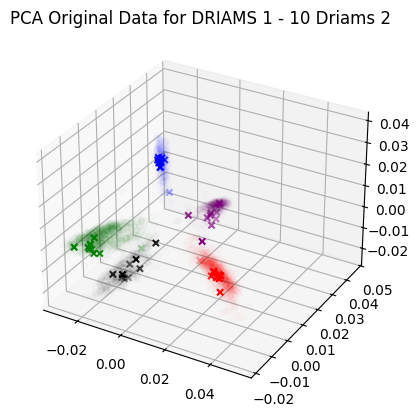

In [89]:
# Ensure you have PCA data and filtered species data
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Unique species
driams_1_labels = filtered_driams_1["species"].unique().tolist()

for i, species in enumerate(driams_1_labels):
    # Filter PCA data for the current species
    mask = filtered_driams_1["species"] == species
    plot_data = pca_driams_1[mask]

    # Scatter plot for this species
    ax.scatter(
        plot_data[:, 0],  # First PCA component
        plot_data[:, 1],  # Second PCA component
        plot_data[:, 2],  # Third PCA component
        c=colors[driams_1_labels.index(species)],  # Avoid index overflow
        label=species,
        alpha=0.01  # Set opacity to 50%
    )

    # Add 10 synthetic samples for each species
    mask = filtered_driams_2["species"] == species
    plot_data = pca_driams_2[mask][:10]
    
    # Scatter plot for this species
    ax.scatter(
        plot_data[:, 0],  # First PCA component
        plot_data[:, 1],  # Second PCA component
        plot_data[:, 2],  # Third PCA component
        c=colors[driams_1_labels.index(species)],  # Avoid index overflow
        label=species,
        marker='x'
    )

ax.set_title("PCA Original Data for DRIAMS 1 - 10 Driams 2")
plt.show()

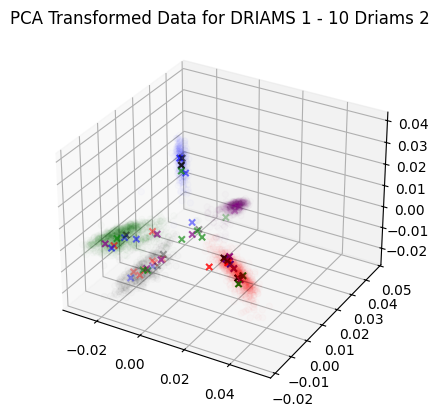

In [ ]:
# Ensure you have PCA data and filtered species data
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Unique species
driams_1_labels = filtered_driams_1["species"].unique().tolist()

for i, species in enumerate(driams_1_labels):
    # Filter PCA data for the current species
    mask = filtered_driams_1["species"] == species
    plot_data = pca_driams_1[mask]

    # Scatter plot for this species
    ax.scatter(
        plot_data[:, 0],  # First PCA component
        plot_data[:, 1],  # Second PCA component
        plot_data[:, 2],  # Third PCA component
        c=colors[driams_1_labels.index(species)],  # Avoid index overflow
        label=species,
        alpha=0.01  # Set opacity to 50%
    )

    # Add 10 synthetic samples for each species
    mask = filtered_driams_2["species"] == species
    plot_data = transformed_pca_driams_2[mask][:10]

    # Scatter plot for this species
    ax.scatter(
        plot_data[:, 0],  # First PCA component
        plot_data[:, 1],  # Second PCA component
        plot_data[:, 2],  # Third PCA component
        c=colors[driams_1_labels.index(species)],  # Avoid index overflow
        label=species,
        marker='x'
    )

ax.set_title("PCA Transformed Data for DRIAMS 1 - 10 Driams 2")
plt.show()